# STL-10 Scrambled Patch Image Reconstruction

This notebook trains a neural network to reconstruct a full 96 x 96 RGB STL-10 image from 9 shuffled 28 x 28 cropped patches. Each patch comes from the center crop of one cell in a 3 x 3 grid, so the model must infer both the shuffled layout and the missing borders.

The solution follows the project constraints: Keras only, no pretrained models, no handcrafted jigsaw solver, per-batch image normalization, and fewer than 6 million trainable parameters.


## Imports and Reproducibility

The full STL-10 array is kept as `uint8`. Conversion to `float32` happens only inside `PatchGenerator.__getitem__` for one batch at a time.


In [ ]:
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
if not tf.config.list_physical_devices("GPU"):
    print("No GPU detected. The notebook will run, but training will be slow.")


TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Google Drive and STL-10 Loading

The loader first searches for `unlabeled_X.bin` inside the Drive dataset folder. If it is missing, it downloads and extracts the official STL-10 binary archive, then searches again. This keeps the path robust across slightly different extraction layouts.


In [ ]:
DRIVE_AVAILABLE = False
try:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_AVAILABLE = True
except Exception as exc:
    print("Google Drive was not mounted in this environment:", exc)


Mounted at /content/drive


In [ ]:
STL10_URL = "http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz"
IMAGE_SHAPE = (96, 96, 3)
IMAGE_PIXELS = 3 * 96 * 96


def find_unlabeled_binary(search_root):
    for dirpath, _, filenames in os.walk(search_root):
        if "unlabeled_X.bin" in filenames:
            return os.path.join(dirpath, "unlabeled_X.bin")
    return None


def default_dataset_root():
    if os.path.exists("/content/drive/MyDrive"):
        return "/content/drive/MyDrive/datasets/stl10"
    return "./stl10_data"


def download_and_load_stl10(dataset_root=None):
    dataset_root = dataset_root or default_dataset_root()
    os.makedirs(dataset_root, exist_ok=True)

    filepath = find_unlabeled_binary(dataset_root)
    if filepath is None:
        print("Downloading STL-10 to:", dataset_root)
        tf.keras.utils.get_file(
            fname="stl10_binary.tar.gz",
            origin=STL10_URL,
            cache_dir=dataset_root,
            extract=True,
        )
        filepath = find_unlabeled_binary(dataset_root)

    if filepath is None:
        raise FileNotFoundError(f"Could not find unlabeled_X.bin inside {dataset_root}")

    print("Loading data from:", filepath)
    with open(filepath, "rb") as f:
        data = np.fromfile(f, dtype=np.uint8)

    if data.size % IMAGE_PIXELS != 0:
        raise ValueError(f"Unexpected STL-10 binary size: {data.size} bytes")

    images = data.reshape((-1, 3, 96, 96))
    images = np.transpose(images, (0, 3, 2, 1))
    print("Loaded images:", images.shape, images.dtype)
    return images


In [ ]:
images = download_and_load_stl10()
assert images.dtype == np.uint8
assert images.shape[1:] == IMAGE_SHAPE

train_images = images[:80000]
val_images = images[80000:90000]
test_images = images[90000:]

print("Train:", train_images.shape)
print("Val:", val_images.shape)
print("Test:", test_images.shape)


Loading data from: /content/drive/MyDrive/datasets/stl10/datasets/stl10_binary_extracted/stl10_binary/unlabeled_X.bin
Loaded images: (100000, 96, 96, 3) uint8
Train: (80000, 96, 96, 3)
Val: (10000, 96, 96, 3)
Test: (10000, 96, 96, 3)


## Memory-Safe Patch Generator

For each image, the generator extracts the centered 28 x 28 crop from each 32 x 32 grid cell, shuffles the 9 crops, and returns the original full image as the reconstruction target.


In [ ]:
class PatchGenerator(keras.utils.PyDataset):
    def __init__(
        self,
        images,
        batch_size=16,
        patch_size=32,
        crop_size=28,
        shuffle=True,
        seed=42,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.images = images
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.crop_size = crop_size
        self.shuffle = shuffle
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.indices = np.arange(len(self.images))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def _patch_order(self, img_idx):
        if self.shuffle:
            return self.rng.permutation(9)
        fixed_seed = int(img_idx) if self.seed is None else self.seed + int(img_idx)
        return np.random.default_rng(fixed_seed).permutation(9)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        actual_batch_size = len(batch_indices)

        X = np.zeros((actual_batch_size, 9, self.crop_size, self.crop_size, 3), dtype="float32")
        Y = np.zeros((actual_batch_size, 96, 96, 3), dtype="float32")
        margin = (self.patch_size - self.crop_size) // 2

        for i, img_idx in enumerate(batch_indices):
            full_img = self.images[img_idx].astype("float32") / 255.0
            Y[i] = full_img

            patches = []
            for row in range(3):
                for col in range(3):
                    y0 = row * self.patch_size
                    x0 = col * self.patch_size
                    cell = full_img[y0 : y0 + self.patch_size, x0 : x0 + self.patch_size, :]
                    crop = cell[margin : margin + self.crop_size, margin : margin + self.crop_size, :]
                    patches.append(crop)

            order = self._patch_order(img_idx)
            for slot_idx, original_pos in enumerate(order):
                X[i, slot_idx] = patches[original_pos]

        return X, Y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.indices)


In [ ]:
BATCH_SIZE = 16  # Use 8 if your Colab GPU/RAM is tight.

train_generator = PatchGenerator(train_images, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_generator = PatchGenerator(val_images, batch_size=BATCH_SIZE, shuffle=False, seed=SEED)
test_generator = PatchGenerator(test_images, batch_size=BATCH_SIZE, shuffle=False, seed=SEED)

X_batch, Y_batch = train_generator[0]
print("X:", X_batch.shape, X_batch.dtype, X_batch.min(), X_batch.max())
print("Y:", Y_batch.shape, Y_batch.dtype, Y_batch.min(), Y_batch.max())

assert X_batch.shape[1:] == (9, 28, 28, 3)
assert Y_batch.shape[1:] == (96, 96, 3)


X: (16, 9, 28, 28, 3) float32 0.0 1.0
Y: (16, 96, 96, 3) float32 0.0 1.0


## Visualize the Input Puzzle

The input canvas below shows the shuffled slots exactly as the model receives them. It does not place patches in their true positions.


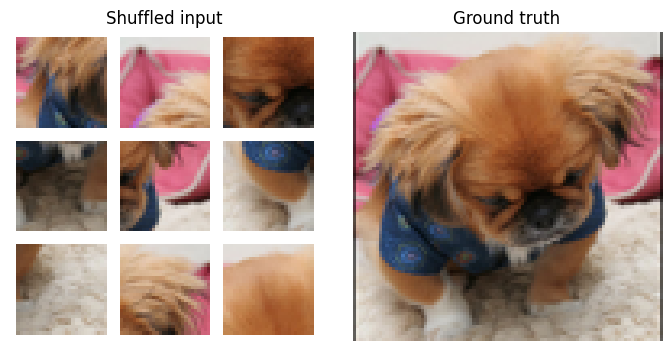

In [ ]:
def scrambled_patch_canvas(patches):
    canvas = np.ones((96, 96, 3), dtype="float32")
    slot = 0
    for row in range(3):
        for col in range(3):
            y0 = row * 32 + 2
            x0 = col * 32 + 2
            canvas[y0 : y0 + 28, x0 : x0 + 28] = patches[slot]
            slot += 1
    return canvas


def show_puzzle_batch(generator, batch_index=0, item_index=0):
    X, Y = generator[batch_index]
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
    axes[0].imshow(scrambled_patch_canvas(X[item_index]))
    axes[0].set_title("Shuffled input")
    axes[1].imshow(Y[item_index])
    axes[1].set_title("Ground truth")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_puzzle_batch(train_generator, batch_index=0, item_index=0)


## Baseline

This baseline is not the final solution. It simply averages the 9 input patches, repeats the mean patch into a grid, and resizes to 96 x 96. The final model below is neural-only.


In [ ]:
def mean_patch_image(patches):
    batch_size = tf.shape(patches)[0]
    mean_patch = tf.reduce_mean(patches, axis=1)
    mean_patches = tf.repeat(mean_patch[:, None, :, :, :], repeats=9, axis=1)
    out = tf.reshape(mean_patches, (batch_size, 3, 3, 28, 28, 3))
    out = tf.transpose(out, [0, 1, 3, 2, 4, 5])
    out = tf.reshape(out, (batch_size, 84, 84, 3))
    return tf.image.resize(out, (96, 96), method="bilinear")


def compute_baseline_mae(generator, max_batches=None):
    mae_values = []
    n_batches = len(generator) if max_batches is None else min(max_batches, len(generator))
    for batch_idx in range(n_batches):
        X, Y = generator[batch_idx]
        preds = mean_patch_image(X)
        batch_mae = tf.reduce_mean(tf.abs(Y - preds), axis=[1, 2, 3])
        mae_values.extend(batch_mae.numpy())
    return np.array(mae_values)


baseline_mae = compute_baseline_mae(test_generator)
print("Baseline test MAE mean:", baseline_mae.mean())
print("Baseline test MAE std:", baseline_mae.std())


Baseline test MAE mean: 0.18236528
Baseline test MAE std: 0.056120716


## Model Architecture

The network uses a shared CNN patch encoder, transformer layers over the 9 unordered patch tokens, learned canvas query tokens that attend to the patch tokens, and a convolutional decoder. It uses random initialization only.


In [ ]:
@keras.utils.register_keras_serializable()
class SlotPositionEmbedding(layers.Layer):
    def __init__(self, num_slots, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_slots = num_slots
        self.embed_dim = embed_dim
        self.embedding = layers.Embedding(num_slots, embed_dim)

    def call(self, inputs):
        positions = tf.range(tf.shape(inputs)[1])
        position_embeddings = self.embedding(positions)
        return inputs + tf.expand_dims(position_embeddings, axis=0)

    def get_config(self):
        config = super().get_config()
        config.update({"num_slots": self.num_slots, "embed_dim": self.embed_dim})
        return config


@keras.utils.register_keras_serializable()
class LearnedCanvasQueries(layers.Layer):
    def __init__(self, num_queries, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_queries = num_queries
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.queries = self.add_weight(
            name="queries",
            shape=(self.num_queries, self.embed_dim),
            initializer="glorot_uniform",
            trainable=True,
        )

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        return tf.tile(tf.expand_dims(self.queries, axis=0), [batch_size, 1, 1])

    def get_config(self):
        config = super().get_config()
        config.update({"num_queries": self.num_queries, "embed_dim": self.embed_dim})
        return config


def transformer_block(x, num_heads, key_dim, mlp_dim, dropout, name):
    attn_input = layers.LayerNormalization(name=f"{name}_attn_norm")(x)
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout,
        name=f"{name}_attention",
    )(attn_input, attn_input)
    x = layers.Add(name=f"{name}_attn_skip")([x, attn_output])

    mlp_input = layers.LayerNormalization(name=f"{name}_mlp_norm")(x)
    mlp_output = layers.Dense(mlp_dim, activation="gelu", name=f"{name}_mlp_in")(mlp_input)
    mlp_output = layers.Dropout(dropout, name=f"{name}_mlp_dropout")(mlp_output)
    mlp_output = layers.Dense(x.shape[-1], name=f"{name}_mlp_out")(mlp_output)
    return layers.Add(name=f"{name}_mlp_skip")([x, mlp_output])


def decoder_conv(x, filters, name):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def build_patch_reconstructor(
    embed_dim=192,
    num_heads=4,
    key_dim=48,
    mlp_dim=384,
    dropout=0.1,
):
    inputs = keras.Input(shape=(9, 28, 28, 3), name="shuffled_patches")

    patch_encoder = keras.Sequential(
        [
            keras.Input(shape=(28, 28, 3)),
            layers.Conv2D(32, 3, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(32, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(64, 3, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(64, 3, strides=2, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.Conv2D(128, 3, padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.GlobalAveragePooling2D(),
            layers.Dense(embed_dim, activation="relu"),
        ],
        name="shared_patch_encoder",
    )

    tokens = layers.TimeDistributed(patch_encoder, name="encode_each_patch")(inputs)
    tokens = SlotPositionEmbedding(9, embed_dim, name="input_slot_embedding")(tokens)

    for block_idx in range(3):
        tokens = transformer_block(
            tokens,
            num_heads=num_heads,
            key_dim=key_dim,
            mlp_dim=mlp_dim,
            dropout=dropout,
            name=f"patch_transformer_{block_idx + 1}",
        )

    tokens = layers.LayerNormalization(name="patch_tokens_norm")(tokens)

    canvas_queries = LearnedCanvasQueries(36, embed_dim, name="learned_canvas_queries")(tokens)
    query_norm = layers.LayerNormalization(name="canvas_query_norm")(canvas_queries)
    key_norm = layers.LayerNormalization(name="canvas_key_norm")(tokens)
    canvas_context = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout,
        name="canvas_cross_attention",
    )(query_norm, key_norm)
    canvas_tokens = layers.Add(name="canvas_cross_attention_skip")([canvas_queries, canvas_context])

    canvas_tokens = transformer_block(
        canvas_tokens,
        num_heads=num_heads,
        key_dim=key_dim,
        mlp_dim=mlp_dim,
        dropout=dropout,
        name="canvas_transformer",
    )
    canvas_tokens = layers.LayerNormalization(name="canvas_tokens_norm")(canvas_tokens)

    x = layers.Reshape((6, 6, embed_dim), name="tokens_to_canvas")(canvas_tokens)
    x = layers.UpSampling2D(name="upsample_to_12")(x)
    x = decoder_conv(x, 192, "decoder_12_a")
    x = decoder_conv(x, 192, "decoder_12_b")

    x = layers.UpSampling2D(name="upsample_to_24")(x)
    x = decoder_conv(x, 128, "decoder_24_a")
    x = decoder_conv(x, 128, "decoder_24_b")

    x = layers.UpSampling2D(name="upsample_to_48")(x)
    x = decoder_conv(x, 96, "decoder_48_a")
    x = decoder_conv(x, 96, "decoder_48_b")

    x = layers.UpSampling2D(name="upsample_to_96")(x)
    x = decoder_conv(x, 64, "decoder_96_a")
    x = decoder_conv(x, 32, "decoder_96_b")

    outputs = layers.Conv2D(3, 3, padding="same", activation="sigmoid", name="reconstruction")(x)
    return keras.Model(inputs, outputs, name="stl10_patch_reconstructor")


model = build_patch_reconstructor()
model.summary()

trainable_params = int(sum(np.prod(weight.shape) for weight in model.trainable_weights))
total_params = model.count_params()
print("Total parameters:", f"{total_params:,}")
print("Trainable parameters:", f"{trainable_params:,}")

assert model.output_shape == (None, 96, 96, 3)
assert trainable_params < 6_000_000


Model: "stl10_patch_reconstructor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ shuffled_patches    │ (None, 9, 28, 28, │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encode_each_patch   │ (None, 9, 192)    │    165,152 │ shuffled_patches… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_slot_embeddi… │ (None, 9, 192)    │      1,728 │ encode_each_patc… │
│ (SlotPositionEmbed… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ input_slot_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ input_slot_embed… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │     73,920 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │    148,224 │ patch_transforme… │
│ (MultiHeadAttentio… │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │          0 │ patch_transforme… │
│ (Add)               │                   │            │ patch_transforme… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 192)    │        384 │ patch_transforme… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │     74,112 │ patch_transforme… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_transformer_… │ (None, 9, 384)    │          0 │ patch_transforme

 Total params: 2,815,683 (10.74 MB)

 Trainable params: 2,813,187 (10.73 MB)

 Non-trainable params: 2,496 (9.75 KB)

Total parameters: 2,815,683
Trainable parameters: 2,813,187


## Compile the Model

The official reported metric is Mean Absolute Error. To reduce blurry average-looking predictions, the default training loss adds a small image-gradient penalty while still monitoring `val_mae` for checkpoint selection.


In [ ]:
EDGE_LOSS_WEIGHT = 0.15
USE_EDGE_AWARE_LOSS = True


def image_gradient_mae(y_true, y_pred):
    true_dy, true_dx = tf.image.image_gradients(y_true)
    pred_dy, pred_dx = tf.image.image_gradients(y_pred)
    dy_mae = tf.reduce_mean(tf.abs(true_dy - pred_dy))
    dx_mae = tf.reduce_mean(tf.abs(true_dx - pred_dx))
    return 0.5 * (dy_mae + dx_mae)


def edge_aware_mae(y_true, y_pred):
    pixel_mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    return pixel_mae + EDGE_LOSS_WEIGHT * image_gradient_mae(y_true, y_pred)


training_loss = edge_aware_mae if USE_EDGE_AWARE_LOSS else "mae"

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=training_loss,
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse"),
    ],
)


## Training and Checkpoints

`RUN_TRAINING=True` trains the model and stores the best validation checkpoint. For a quick smoke test, set `EPOCHS=1`; for a real submission run, train longer and use the best validation checkpoint.


In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/patch_project" if os.path.exists("/content/drive/MyDrive") else "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model.weights.h5")
FINAL_WEIGHTS_PATH = os.path.join(OUTPUT_DIR, "final_model.weights.h5")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_mae",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode="min",
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=8,
        restore_best_weights=True,
        mode="min",
        verbose=1,
    ),
]

RUN_TRAINING = True
EPOCHS = 30

if RUN_TRAINING:
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
    )
    model.save_weights(FINAL_WEIGHTS_PATH)
    print("Saved final weights to:", FINAL_WEIGHTS_PATH)
else:
    history = None
    print("Training skipped.")

Epoch 1/30
4999/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1767 - mae: 0.1692 - mse: 0.0503
Epoch 1: val_mae improved from None to 0.15051, saving model to /content/drive/MyDrive/patch_project/best_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/patch_project/best_model.weights.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 184s 19ms/step - loss: 0.1663 - mae: 0.1589 - mse: 0.0458 - val_loss: 0.1579 - val_mae: 0.1505 - val_mse: 0.0439 - learning_rate: 3.0000e-04
Epoch 2/30
4999/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1524 - mae: 0.1451 - mse: 0.0400
Epoch 2: val_mae improved from 0.15051 to 0.13345, saving model to /content/drive/MyDrive/patch_project/best_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/patch_project/best_model.weights.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - loss: 0.1497 - mae: 0.1423 - mse: 0.0389 - val_loss: 0.1408 - val_mae: 0.1334 - val_mse: 0.0362 - learning_rate: 3.0000e-04
Epoch 3/30
4999/5000 ━━━

## Optional Sharpness Fine-Tuning

If a trained checkpoint already has good MAE but looks blurry, set `RUN_TRAINING=False` above and `RUN_SHARPNESS_FINE_TUNING=True` below. This reloads the best MAE checkpoint, continues with a lower learning rate and the edge-aware loss, and still saves according to `val_mae`.


In [ ]:
SHARP_CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "best_model_sharp.weights.h5")
RUN_SHARPNESS_FINE_TUNING = True
SHARPNESS_FINE_TUNE_EPOCHS = 8

if RUN_SHARPNESS_FINE_TUNING:
    if os.path.exists(CHECKPOINT_PATH):
        model.load_weights(CHECKPOINT_PATH)
        print("Loaded checkpoint for sharpness fine-tuning:", CHECKPOINT_PATH)
    else:
        print("No existing checkpoint found; fine-tuning will start from current model weights.")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss=edge_aware_mae,
        metrics=[
            keras.metrics.MeanAbsoluteError(name="mae"),
            keras.metrics.MeanSquaredError(name="mse"),
        ],
    )

    sharp_callbacks = [
        keras.callbacks.ModelCheckpoint(
            SHARP_CHECKPOINT_PATH,
            monitor="val_mae",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            mode="min",
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_mae",
            patience=4,
            restore_best_weights=True,
            mode="min",
            verbose=1,
        ),
    ]

    history_sharp = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=SHARPNESS_FINE_TUNE_EPOCHS,
        callbacks=sharp_callbacks,
    )

    if os.path.exists(SHARP_CHECKPOINT_PATH):
        model.load_weights(SHARP_CHECKPOINT_PATH)
        CHECKPOINT_PATH = SHARP_CHECKPOINT_PATH
        print("Using sharpness-tuned checkpoint for evaluation:", CHECKPOINT_PATH)
else:
    history_sharp = None
    print("Sharpness fine-tuning skipped.")


Loaded checkpoint for sharpness fine-tuning: /content/drive/MyDrive/patch_project/best_model.weights.h5
Epoch 1/8
4998/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0973 - mae: 0.0902 - mse: 0.0195
Epoch 1: val_mae improved from None to 0.08719, saving model to /content/drive/MyDrive/patch_project/best_model_sharp.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/patch_project/best_model_sharp.weights.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 157s 19ms/step - loss: 0.0968 - mae: 0.0897 - mse: 0.0194 - val_loss: 0.0943 - val_mae: 0.0872 - val_mse: 0.0193 - learning_rate: 1.0000e-04
Epoch 2/8
4998/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0959 - mae: 0.0887 - mse: 0.0190
Epoch 2: val_mae improved from 0.08719 to 0.08683, saving model to /content/drive/MyDrive/patch_project/best_model_sharp.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/patch_project/best_model_sharp.weights.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 86s 17ms/step - loss: 0.0959 - mae: 0.

## Load Weights with gdown

After training, upload `best_model.weights.h5` to Google Drive, create a shareable link, paste its file ID below, and rerun this cell. The placeholder keeps the notebook runnable before a final trained file exists.


In [ ]:
GDOWN_FILE_ID = "YOUR_FILE_ID_HERE"
GDOWN_OUTPUT = "best_model.weights.h5"

if GDOWN_FILE_ID != "YOUR_FILE_ID_HERE":
    !pip install -q gdown
    !gdown "https://drive.google.com/uc?id={GDOWN_FILE_ID}" -O "{GDOWN_OUTPUT}"
    model.load_weights(GDOWN_OUTPUT)
    print("Loaded weights from gdown file:", GDOWN_OUTPUT)
elif os.path.exists(CHECKPOINT_PATH):
    model.load_weights(CHECKPOINT_PATH)
    print("Loaded local best checkpoint:", CHECKPOINT_PATH)
else:
    print("No gdown file ID or local checkpoint found yet.")


Loaded local best checkpoint: /content/drive/MyDrive/patch_project/best_model_sharp.weights.h5


## Training Curves


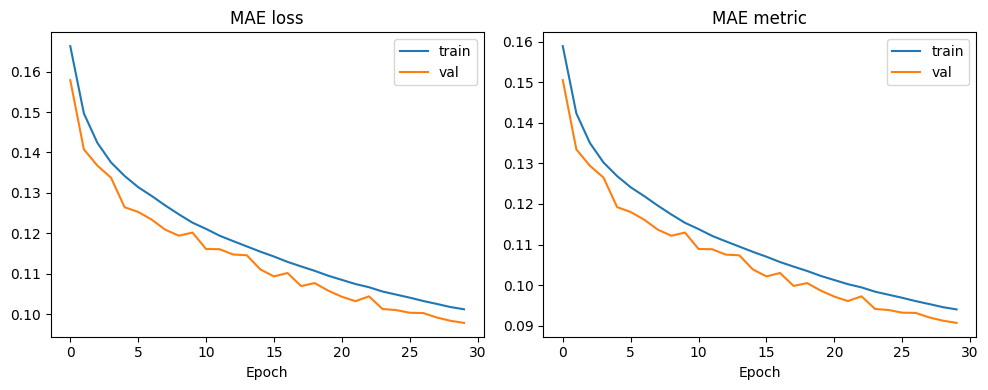

In [ ]:
def plot_training_history(history):
    if history is None:
        print("No training history to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history.history.get("loss", []), label="train")
    axes[0].plot(history.history.get("val_loss", []), label="val")
    axes[0].set_title("MAE loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history.get("mae", []), label="train")
    axes[1].plot(history.history.get("val_mae", []), label="val")
    axes[1].set_title("MAE metric")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_training_history(history)


## Test Evaluation

The official report is the mean and standard deviation of per-image MAE over the STL-10 test split.


In [ ]:
def compute_model_mae(model, generator, max_batches=None):
    mae_values = []
    n_batches = len(generator) if max_batches is None else min(max_batches, len(generator))
    for batch_idx in range(n_batches):
        X, Y = generator[batch_idx]
        preds = model.predict(X, verbose=0)
        batch_mae = tf.reduce_mean(tf.abs(Y - preds), axis=[1, 2, 3])
        mae_values.extend(batch_mae.numpy())
    return np.array(mae_values)


if os.path.exists(CHECKPOINT_PATH):
    model.load_weights(CHECKPOINT_PATH)
    print("Evaluating best checkpoint:", CHECKPOINT_PATH)

mae_values = compute_model_mae(model, test_generator)
print("Test MAE mean:", mae_values.mean())
print("Test MAE std:", mae_values.std())


Evaluating best checkpoint: /content/drive/MyDrive/patch_project/best_model_sharp.weights.h5
Test MAE mean: 0.08528282
Test MAE std: 0.037535794


## Visual Reconstruction Examples


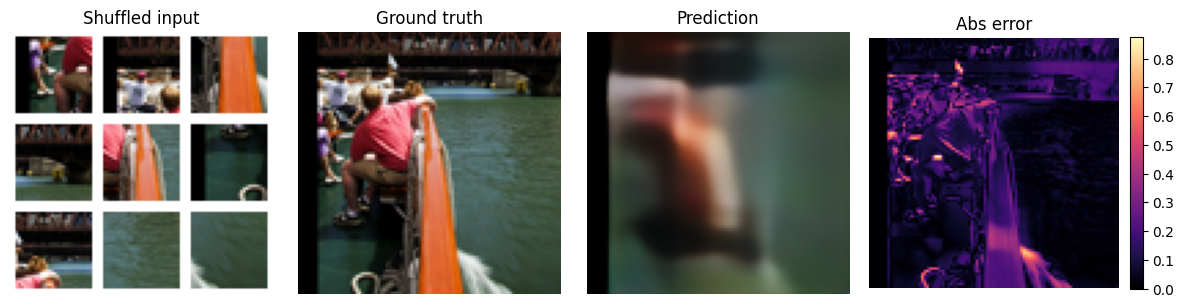

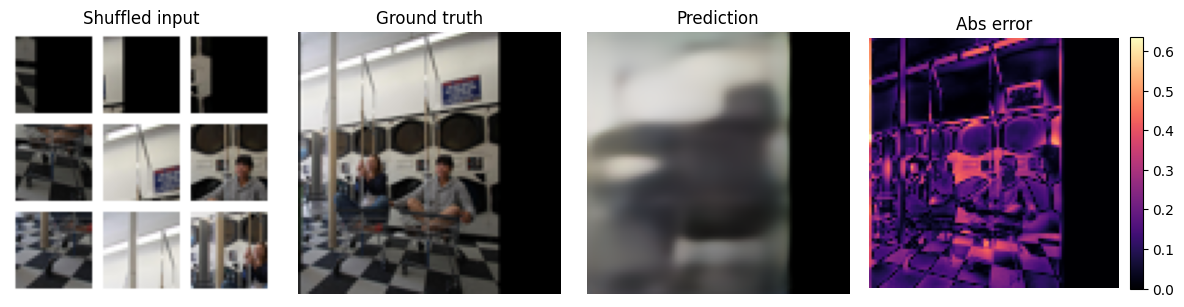

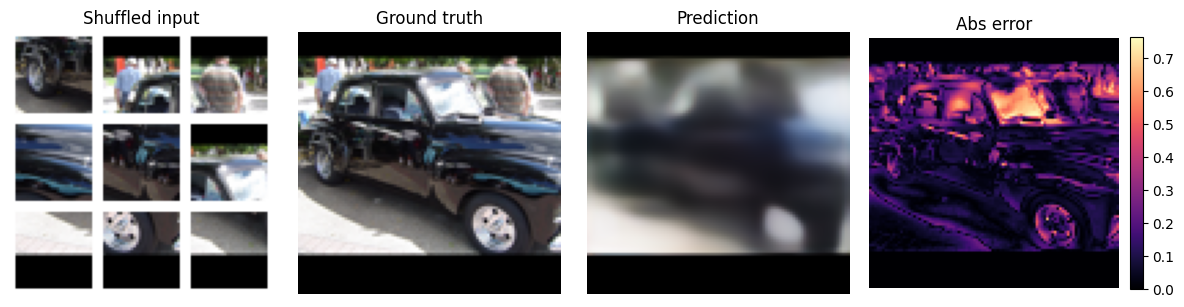

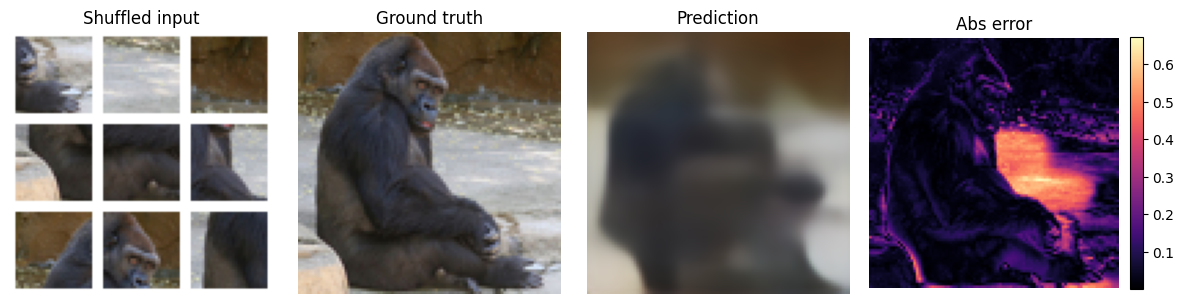

In [ ]:
def show_predictions(model, generator, batch_index=0, max_items=4):
    X, Y = generator[batch_index]
    preds = model.predict(X[:max_items], verbose=0)

    for i in range(min(max_items, len(preds))):
        error = np.mean(np.abs(Y[i] - preds[i]), axis=-1)
        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        axes[0].imshow(scrambled_patch_canvas(X[i]))
        axes[0].set_title("Shuffled input")
        axes[1].imshow(Y[i])
        axes[1].set_title("Ground truth")
        axes[2].imshow(np.clip(preds[i], 0.0, 1.0))
        axes[2].set_title("Prediction")
        im = axes[3].imshow(error, cmap="magma")
        axes[3].set_title("Abs error")
        for ax in axes:
            ax.axis("off")
        fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()


show_predictions(model, test_generator, batch_index=0, max_items=4)


## Final Results Summary

Fill in the gdown file ID after uploading the trained best checkpoint. The printed values below are produced by the executed notebook and should be copied into the final report cell after the final training run.


In [ ]:
print("Final model: CNN patch encoder + patch transformer + learned canvas cross-attention + convolutional decoder")
print("Trainable parameters:", f"{trainable_params:,}")
print("Parameter limit satisfied:", trainable_params < 6_000_000)

if "baseline_mae" in globals():
    print("Baseline test MAE mean:", baseline_mae.mean())
    print("Baseline test MAE std:", baseline_mae.std())

if "mae_values" in globals():
    print("Test MAE mean:", mae_values.mean())
    print("Test MAE std:", mae_values.std())
else:
    print("Run the evaluation cell to produce final test MAE values.")


Final model: CNN patch encoder + patch transformer + learned canvas cross-attention + convolutional decoder
Trainable parameters: 2,813,187
Parameter limit satisfied: True
Baseline test MAE mean: 0.18236528
Baseline test MAE std: 0.056120716
Test MAE mean: 0.08528282
Test MAE std: 0.037535794


## Constraint Checklist

- Neural network solution only: shared CNN, attention, learned canvas queries, convolutional decoder.
- No pretrained models or external feature extractors.
- No handcrafted permutation search, edge matching, or explicit jigsaw solver.
- STL-10 data remains `uint8`; normalization is per batch in the generator.
- Model output shape is asserted as `(None, 96, 96, 3)`.
- Trainable parameter count is asserted below 6,000,000.
- Best weights are saved as `.weights.h5` and can be loaded through `gdown` after uploading to Drive.
